## Perform Bias/Risk Assesment of Model 

In [1]:
import numpy as np
import pandas as pd
%pip install shap
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

From https://github.com/tongyuguo/HelpHerInvest
   774b74f..b804b87  main       -> origin/main


Updating 774b74f..b804b87
Fast-forward
 Code Outputs/Week 10/week10_data_centric_model.pdf |  Bin 0 -> 213684 bytes
 Notebooks/Week 10/week10_data_centric_model.ipynb  | 4254 ++++++++++++++++++++
 .../week11_bias_assessment_modell01.ipynb          | 1741 ++++++++
 Reports/Week 10/test.html                          |    1 +
 .../week10_helpherinvest_written_report.pdf        |  Bin 0 -> 421770 bytes
 .../week11_helpherinvest_written_report.pdf        |  Bin 0 -> 222349 bytes
 6 files changed, 5996 insertions(+)
 create mode 100644 Code Outputs/Week 10/week10_data_centric_model.pdf
 create mode 100644 Notebooks/Week 10/week10_data_centric_model.ipynb
 create mode 100644 Playground/Week 11 Explain the model, analyze risk, bias and ethical considerations/Chris Playground/week11_bias_assessment_modell01.ipynb
 create mode 100644 Reports/Week 10/test.html
 create mode 100644 Reports/Week 10/week10_helpherinvest_written_report.pdf
 create mode 100644 Reports/Week 11/week11_helpherinvest_writt

In [3]:
# Load the data from the zip file

## PATH NEEDS TO BE UPDATED TO GITHUB DATA PATH
zip_path2 = "HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

## ## ## ## 

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


In [4]:
# count number of positive fwd_excess_return
print("Number of positive fwd_excess_return:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess_return:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess_return:", (df["fwd_excess"] == 0).sum())

df_temp = df.copy()

df_temp['y'] = (df_temp['fwd_excess'] > 0).astype(int)



Number of positive fwd_excess_return: 143948
Number of negative fwd_excess_return: 151730
Number of zero fwd_excess_return: 287


In [5]:
df = df_temp.dropna()
print("---  ---  ---")
print("Length of original:",len(df_temp.index))
print("Length of dropped:",len(df.index))

---  ---  ---
Length of original: 302024
Length of dropped: 274511


### Create Winning Dataset - Cross Sectionally Ranked

In [6]:
rank_cols = [
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_ex_1m',
    'rel_3m_spy','rel_6m_spy','rel_12m_spy',
    'vol_3m','vol_6m',
    'drawdown_6m','drawdown_12m',
    'pct_above_200dma'
]

df_rank = df.copy()

for col in rank_cols:
    df_rank[col] = df_rank.groupby("Date")[col].rank(pct=True)

#df_rank[rank_cols].head(10)

In [7]:
df_rank["fwd_rank"] = df_rank.groupby("Date")["fwd_excess"].rank(pct=True)

df_rank["target"] = pd.cut(
    df_rank["fwd_rank"],
    bins=[0, .2, .4, .6, .8, 1],
    labels=[0,1,2,3,4]
)

df_rank.head(10)

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,...,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,fwd_rank,target
13389,2011-01-31,NVDA,0.997496,0.995826,0.995826,0.814691,0.137730,0.995826,0.995826,0.814691,...,0.928214,0.744157,0.790067,0.995826,0.5483,-0.2287,-0.1639,0,0.030050,0
13390,2011-01-31,GOOGL,0.480801,0.142738,0.636060,0.281302,0.276294,0.142738,0.636060,0.281302,...,0.438230,0.377295,0.476628,0.515025,14.9114,-0.1585,-0.0937,0,0.070117,0
13391,2011-01-31,AAPL,0.729549,0.623539,0.766277,0.909015,0.889816,0.623539,0.766277,0.909015,...,0.222871,0.744157,0.790067,0.747913,10.1670,-0.0330,0.0319,0,0.317195,1
13392,2011-01-31,MSFT,0.381469,0.343907,0.277963,0.121870,0.144407,0.343907,0.277963,0.121870,...,0.181135,0.450751,0.256260,0.288815,21.1071,-0.1246,-0.0597,0,0.101836,0
13393,2011-01-31,AMZN,0.152755,0.280467,0.883973,0.601836,0.727045,0.280467,0.883973,0.601836,...,0.666110,0.220367,0.330968,0.607679,8.4820,0.0894,0.1543,1,0.747913,3
13394,2011-01-31,AVGO,0.479967,0.727045,0.768781,0.868114,0.873957,0.727045,0.768781,0.868114,...,0.817195,0.744157,0.790067,0.839733,2.0278,0.1036,0.1685,1,0.787145,3
13396,2011-01-31,BRK-B,0.545910,0.282137,0.193656,0.191987,0.180301,0.282137,0.193656,0.191987,...,0.076795,0.426544,0.527546,0.192821,81.7500,-0.0459,0.0190,0,0.267947,1
13397,2011-01-31,LLY,0.373122,0.210351,0.120200,0.154424,0.184474,0.210351,0.120200,0.154424,...,0.035893,0.308848,0.414023,0.149833,24.0450,0.0144,0.0793,1,0.492487,2
13398,2011-01-31,WMT,0.665275,0.327212,0.330551,0.196160,0.166945,0.327212,0.330551,0.196160,...,0.010017,0.744157,0.790067,0.309683,13.7084,-0.0774,-0.0126,0,0.181970,0
13399,2011-01-31,JPM,0.760434,0.785476,0.361436,0.322204,0.227880,0.785476,0.361436,0.322204,...,0.493322,0.744157,0.790067,0.526711,29.9574,-0.0440,0.0209,0,0.276711,1


In [8]:

def time_split(
    df,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    sort_dates=True
):
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("train_frac + val_frac + test_frac must equal 1.0")

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    if sort_dates:
        data = data.sort_values(date_col)

    unique_dates = pd.Series(data[date_col].drop_duplicates()).sort_values().reset_index(drop=True)

    n_dates = len(unique_dates)
    train_end = int(n_dates * train_frac)
    val_end = int(n_dates * (train_frac + val_frac))

    train_dates = unique_dates.iloc[:train_end]
    val_dates = unique_dates.iloc[train_end:val_end]
    test_dates = unique_dates.iloc[val_end:]

    train_df = data[data[date_col].isin(train_dates)].copy()
    val_df = data[data[date_col].isin(val_dates)].copy()
    test_df = data[data[date_col].isin(test_dates)].copy()

    return train_df, val_df, test_df



### Preprocess the Data 

In [9]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

In [10]:
def retrieve_features(df):
    feature_cols = [col for col in df.columns if col not in ["Date", "Ticker", "fwd_excess", "fwd_return", "y","fwd_rank","target"]]
    return feature_cols

In [11]:
# Dataset 1 - Using Ranked Features

train_df_rank, val_df_rank, test_df_rank = time_split(df_rank, date_col="Date", train_frac=0.70, val_frac=0.15, test_frac=0.15)
X_train_rank = train_df_rank[retrieve_features(train_df_rank)]
y_train_rank = train_df_rank["y"]
X_val_rank = val_df_rank[retrieve_features(val_df_rank)]
y_val_rank = val_df_rank["y"]
X_test_rank = test_df_rank[retrieve_features(test_df_rank)]
y_test_rank = test_df_rank["y"]



### Light Gradient Boosting Machine (LightGBM) Models

In [12]:
# Winning LightGBM Model - Dataset 1

import lightgbm as lgb

lgb_model1 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model1.fit(
    X_train_rank,
    y_train_rank,
    eval_set=[(X_val_rank, y_val_rank)],

)

[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score


## Used to Evaluate the Logistic Regression and LightGBM models ##
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))
    print("F1:", round(f1_score(y_test, y_pred, average='macro'), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs, average='macro'), 4))


print("LightGBM Model 1:")
evaluate(lgb_model1, X_val_rank, y_val_rank)
print("------------  --------------  ------------  --------------")


LightGBM Model 1:
Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.53      0.53     24830
           1       0.50      0.51      0.50     22658

    accuracy                           0.52     47488
   macro avg       0.52      0.52      0.52     47488
weighted avg       0.52      0.52      0.52     47488

F1: 0.5175
ROC-AUC: 0.5234
------------  --------------  ------------  --------------



Cross Sectional Ranked
          Pred 0  Pred 1
Actual 0   13127   11703
Actual 1   11180   11478


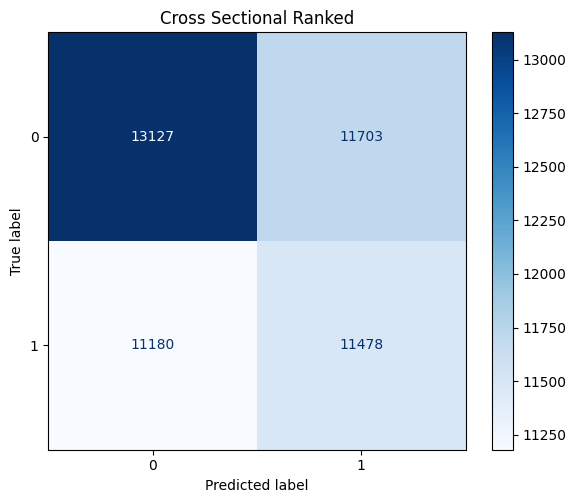

,Pred 0,Pred 1
Actual 0,13127,11703
Actual 1,11180,11478


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def create_confusion_matrix(model, X_val, y_val, name):
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    print(f"\n{name}")
    print(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return cm_df


create_confusion_matrix(lgb_model1, X_val_rank, y_val_rank, "Cross Sectional Ranked")



In [15]:
# Selected the best model from validation performance and evaluate on test set
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("LightGBM Model 1 - Test Set:")
evaluate(lgb_model1, X_test_rank, y_test_rank)



-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
LightGBM Model 1 - Test Set:
Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.52      0.53     26761
           1       0.48      0.49      0.49     23561

    accuracy                           0.51     50322
   macro avg       0.51      0.51      0.51     50322
weighted avg       0.51      0.51      0.51     50322

F1: 0.5087
ROC-AUC: 0.5126


### Determining Important Features

             feature  importance
10       drawdown_6m        5298
11      drawdown_12m        3889
13         adj_close        3592
9             vol_6m        2783
1             mom_3m        2351
2             mom_6m        2222
0             mom_1m        2194
8             vol_3m        2150
3            mom_12m        1997
4      mom_12m_ex_1m        1926
12  pct_above_200dma        1598
5         rel_3m_spy           0
6         rel_6m_spy           0
7        rel_12m_spy           0


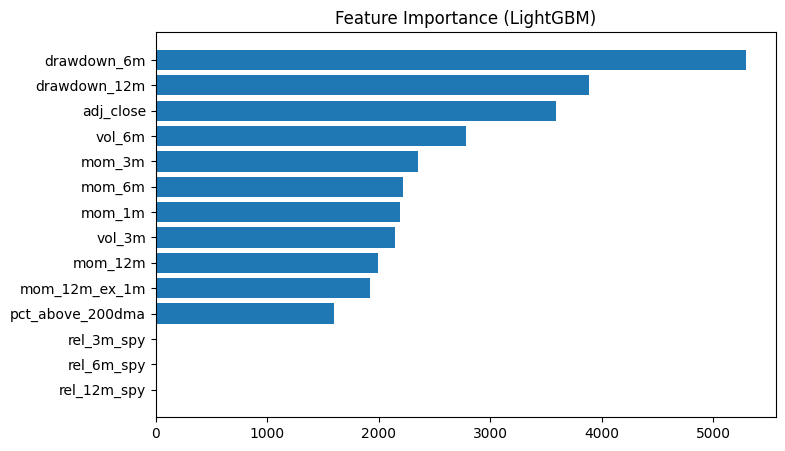

In [16]:
importance = pd.DataFrame({
    "feature": X_train_rank.columns,
    "importance": lgb_model1.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(15))

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance["feature"][:15][::-1], importance["importance"][:15][::-1])
plt.title("Feature Importance (LightGBM)")
plt.show()

In [17]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgb_model1, X_val_rank, y_val_rank,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_importance = pd.DataFrame({
    "feature": X_val_rank.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(perm_importance.head(15))

             feature  importance
1             mom_3m    0.040786
0             mom_1m    0.019287
3            mom_12m    0.012487
13         adj_close    0.009978
2             mom_6m    0.004466
5         rel_3m_spy    0.000000
7        rel_12m_spy    0.000000
6         rel_6m_spy    0.000000
8             vol_3m   -0.000038
4      mom_12m_ex_1m   -0.001346
9             vol_6m   -0.001655
12  pct_above_200dma   -0.001883
11      drawdown_12m   -0.009322
10       drawdown_6m   -0.034162


In [18]:
#%pip install shap
import shap
import pandas as pd
import numpy as np

# Fit explainer (LightGBM example)
explainer = shap.TreeExplainer(lgb_model1)
shap_values = explainer.shap_values(X_val_rank)

# For binary classification, use class 1
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Mean absolute SHAP values = global importance
importance_df = pd.DataFrame({
    "feature": X_val_rank.columns,
    "importance": np.abs(shap_vals).mean(axis=0)
}).sort_values(by="importance", ascending=False)

top_features = importance_df.head(10)
print(top_features)

             feature  importance
10       drawdown_6m    0.063273
11      drawdown_12m    0.060172
9             vol_6m    0.048394
13         adj_close    0.035371
2             mom_6m    0.027896
4      mom_12m_ex_1m    0.019576
8             vol_3m    0.018278
0             mom_1m    0.016098
3            mom_12m    0.013657
12  pct_above_200dma    0.012992


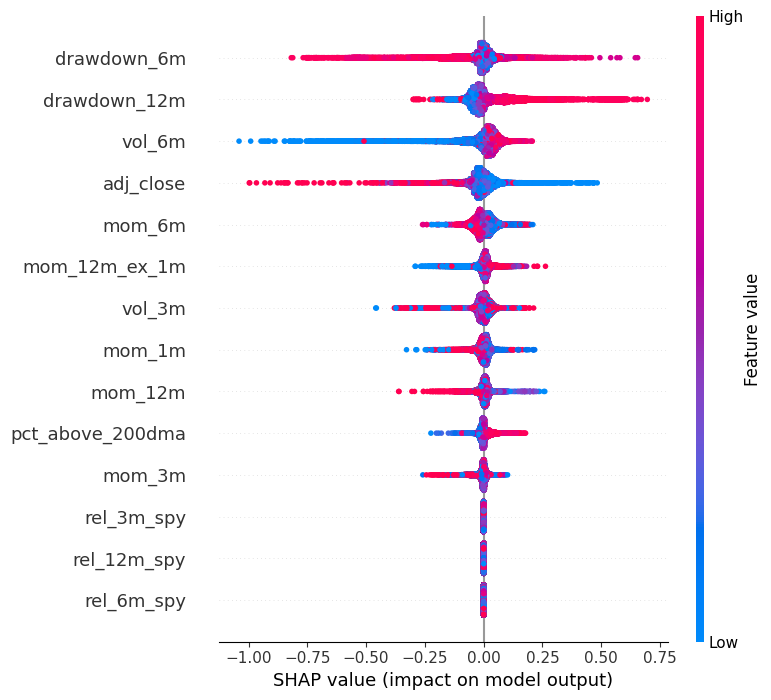

In [19]:
shap.summary_plot(shap_vals, X_val_rank)

In [20]:
sample_pos = np.random.choice(len(X_val_rank), size=5, replace=False)
X_sample = X_val_rank.iloc[sample_pos]
shap_sample = shap_vals[sample_pos]

In [21]:
import random
random.seed(42)

for i, idx in enumerate(sample_pos):
    print(f"\n--- Prediction {i+1} (Index {idx}) ---")
    
    row = X_val_rank.iloc[idx]
    shap_row = shap_sample[i]
    
    # Combine into DataFrame
    explanation = pd.DataFrame({
        "feature": X_val_rank.columns,
        "value": row.values,
        "shap_impact": shap_row
    }).sort_values(by="shap_impact", key=abs, ascending=False)
    
    print(explanation.head(10))  # Top drivers


--- Prediction 1 (Index 45698) ---
             feature      value  shap_impact
9             vol_6m   0.081510    -0.061590
0             mom_1m   0.359409     0.043662
12  pct_above_200dma   0.254923    -0.028787
2             mom_6m   0.334792     0.023826
10       drawdown_6m   0.168490     0.022338
11      drawdown_12m   0.289934    -0.018990
4      mom_12m_ex_1m   0.705142     0.010675
1             mom_3m   0.060722    -0.010581
13         adj_close  92.137600    -0.008547
3            mom_12m   0.648796     0.003924

--- Prediction 2 (Index 17185) ---
             feature     value  shap_impact
9             vol_6m  0.002875    -0.665546
8             vol_3m  0.002875    -0.143544
11      drawdown_12m  0.930995     0.075395
10       drawdown_6m  0.914319    -0.070043
13         adj_close  9.890000    -0.067423
2             mom_6m  0.673951    -0.060178
1             mom_3m  0.676251    -0.047705
4      mom_12m_ex_1m  0.449684     0.044313
0             mom_1m  0.833237     0.

In [22]:
explanation.head(5)

,feature,value,shap_impact
13,adj_close,353.951000,-0.087460
4,mom_12m_ex_1m,0.565067,0.031887
3,mom_12m,0.606709,0.025380
0,mom_1m,0.625217,0.021654
10,drawdown_6m,0.484962,0.016028


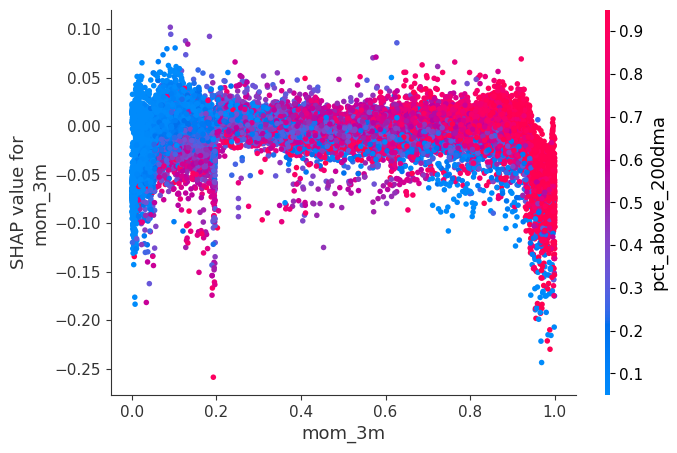

In [23]:
shap.dependence_plot("mom_3m", shap_vals, X_val_rank)